# 04. Returns and Volatility (building the features)
In class, *Data Encoding* turned text into numbers (`map`, `get_dummies`). Our raw material is prices, and in this notebook we turn them into the numbers the models need: **returns**, **squared returns**, and the **target** — next week's volatility.

* **Needs:** `work/clean_ISEQ.csv`. **Makes:** `work/iseq_features.csv`.

*Simple notebook series of the project 'This Time Is Different?'. Prepared with AI assistance (declared in `notes/ai_use.md`); a study notebook, not dissertation text.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder = '/content/drive/MyDrive/DataSets/ThisTimeIsDifferent/'

import warnings
warnings.filterwarnings('ignore')     # hide warning messages

In [2]:
from pandas import read_csv
data1 = read_csv(folder + 'work/clean_ISEQ.csv', index_col=0, parse_dates=True)
data1.head()

,High,Low,Close
2002-10-01,3882.870117,3813.500000,3863.100098
2002-10-02,3942.629883,3859.600098,3926.350098
2002-10-03,3933.560059,3871.360107,3875.959961
2002-10-04,3887.030029,3840.580078,3842.899902
2002-10-07,3843.040039,3736.889893,3748.659912


## 1. The daily return
The **log return** is the daily percentage change: $r_t = \ln(P_t / P_{t-1})$.

Example by hand: the price moves from 100 to 102 → $\ln(102/100) = 0.0198$, about +2%.

In [3]:
from numpy import log
print(log(102 / 100))

0.01980262729617973


`log(...)` of the whole column, then `.diff()` (today minus yesterday) gives every daily return at once:

In [4]:
data1['ret'] = log(data1['Close']).diff()
data1.head()

,High,Low,Close,ret
2002-10-01,3882.870117,3813.500000,3863.100098,NaN
2002-10-02,3942.629883,3859.600098,3926.350098,0.016240
2002-10-03,3933.560059,3871.360107,3875.959961,-0.012917
2002-10-04,3887.030029,3840.580078,3842.899902,-0.008566
2002-10-07,3843.040039,3736.889893,3748.659912,-0.024829


The first row is empty (`NaN`): there is no yesterday for the first day.

## 2. The squared return — the size of the move
The sign of a return says up or down (direction). Its **square** is always positive and says **how big** the move was. A day of −3% and a day of +3% have the same squared return.

In [5]:
data1['r2'] = data1['ret'] ** 2
data1[['ret', 'r2']].loc['2008-09-26':'2008-10-02']

,ret,r2
2008-09-26,-0.010882,0.000118
2008-09-29,-0.139636,0.019498
2008-09-30,0.075776,0.005742
2008-10-01,0.025213,0.000636
2008-10-02,0.048682,0.002370


## 3. The target: next week's realised variance
We want to forecast, after the close of day *t*, **how much the market will move over the next five trading days**:

$RV5_t = r_{t+1}^2 + r_{t+2}^2 + r_{t+3}^2 + r_{t+4}^2 + r_{t+5}^2$

`shift(-1)` moves a column **up** by one row, so each row sees **tomorrow's** value. A small example:

In [6]:
demo = data1[['r2']].loc['2008-09-24':'2008-10-03'].copy()
demo['r2_tomorrow'] = demo['r2'].shift(-1)
demo['r2_in_2_days'] = demo['r2'].shift(-2)
demo

,r2,r2_tomorrow,r2_in_2_days
2008-09-24,0.000089,0.000182,0.000118
2008-09-25,0.000182,0.000118,0.019498
2008-09-26,0.000118,0.019498,0.005742
2008-09-29,0.019498,0.005742,0.000636
2008-09-30,0.005742,0.000636,0.002370
2008-10-01,0.000636,0.002370,0.000967
2008-10-02,0.002370,0.000967,NaN
2008-10-03,0.000967,NaN,NaN


Adding the next five days gives the target:

In [7]:
data1['rv5_fwd'] = data1['r2'].shift(-1) + data1['r2'].shift(-2) + data1['r2'].shift(-3) + data1['r2'].shift(-4) + data1['r2'].shift(-5)
data1[['r2', 'rv5_fwd']].head(8)

,r2,rv5_fwd
2002-10-01,NaN,0.001136
2002-10-02,0.000264,0.001831
2002-10-03,0.000167,0.001708
2002-10-04,0.000073,0.003915
2002-10-07,0.000616,0.003316
2002-10-08,0.000016,0.004541
2002-10-09,0.000959,0.003683
2002-10-10,0.000044,0.004022


## 4. A number we can read: annualised volatility
Variance is hard to read. Volatility (the square root), scaled to a year, is the usual way to talk about risk: **about 15–20% is a normal year**.

In [8]:
from numpy import sqrt
data1['vol_annual'] = sqrt(data1['rv5_fwd'] * 252 / 5)
data1['vol_annual'].describe()

count    5893.000000
mean        0.177766
std         0.121998
min         0.013445
25%         0.104056
50%         0.144146
75%         0.210754
max         1.213382
Name: vol_annual, dtype: float64

<Axes: title={'center': 'Next-week volatility of the ISEQ, 2007-2009 (annualised)'}>

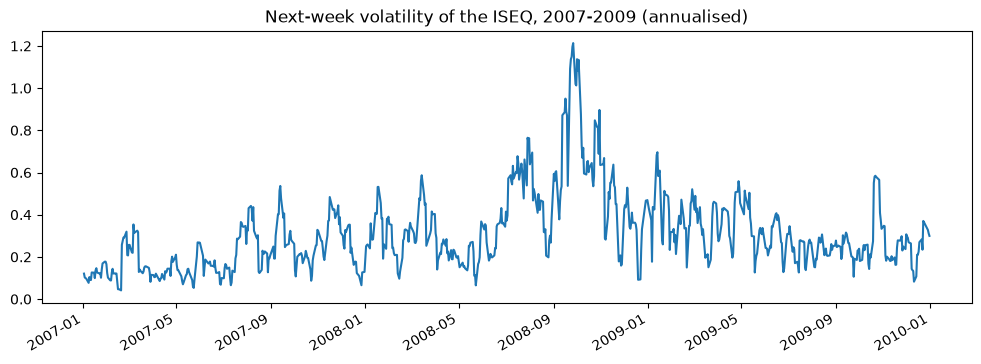

In [9]:
data1['vol_annual'].loc['2007':'2009'].plot(figsize=(12, 4), title='Next-week volatility of the ISEQ, 2007-2009 (annualised)')

In October 2008 the next-week volatility reached about 120% — six times a normal year.

## 5. Why the models learn the logarithm
Volatility is very **skewed**: most weeks are calm (small numbers), a few are huge. In logs it looks much more like a bell curve, which is easier to learn.

<Axes: title={'center': 'rv5_fwd'}, ylabel='Frequency'>

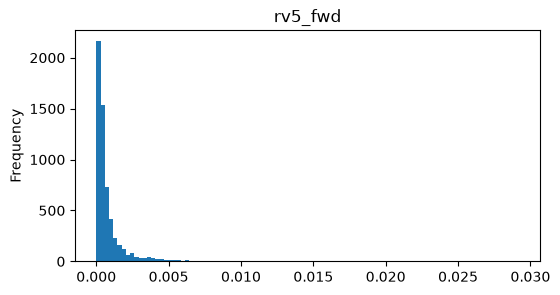

In [10]:
data1['log_rv5_fwd'] = log(data1['rv5_fwd'])
data1['rv5_fwd'].plot(kind='hist', bins=100, figsize=(6, 3), title='rv5_fwd')

<Axes: title={'center': 'log of rv5_fwd'}, ylabel='Frequency'>

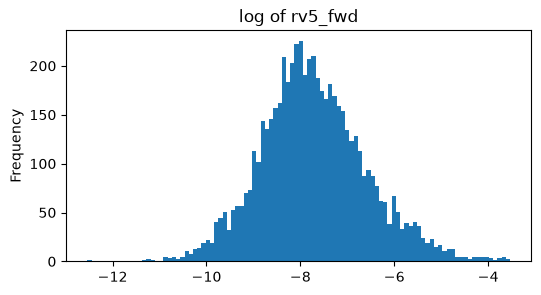

In [11]:
data1['log_rv5_fwd'].plot(kind='hist', bins=100, figsize=(6, 3), title='log of rv5_fwd')

## 6. The ingredients of the HAR model
The HAR benchmark (notebook 09) uses three averages of past squared returns:
* `rv_d` — **today**,
* `rv_w` — the average of the **last 5 days** (one week),
* `rv_m` — the average of the **last 22 days** (one month).

`rolling(5).mean()` takes the average of the last 5 rows, moving forward one row at a time:

In [12]:
data1['rv_d'] = data1['r2']
data1['rv_w'] = data1['r2'].rolling(5).mean()
data1['rv_m'] = data1['r2'].rolling(22).mean()
data1[['r2', 'rv_d', 'rv_w', 'rv_m']].iloc[20:26]

,r2,rv_d,rv_w,rv_m
2002-10-29,2.582244e-04,2.582244e-04,0.000160,NaN
2002-10-30,6.828182e-07,6.828182e-07,0.000154,NaN
2002-10-31,1.124808e-03,1.124808e-03,0.000316,0.000380
2002-11-01,4.220538e-05,4.220538e-05,0.000312,0.000370
2002-11-04,1.544824e-03,1.544824e-03,0.000594,0.000433
2002-11-05,2.932061e-04,2.932061e-04,0.000601,0.000443


## Save

In [13]:
data1 = data1.drop(columns=['vol_annual'])
data1.to_csv(folder + 'work/iseq_features.csv')
data1.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5898 entries, 2002-10-01 to 2025-12-30
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   High         5898 non-null   float64
 1   Low          5898 non-null   float64
 2   Close        5898 non-null   float64
 3   ret          5897 non-null   float64
 4   r2           5897 non-null   float64
 5   rv5_fwd      5893 non-null   float64
 6   log_rv5_fwd  5893 non-null   float64
 7   rv_d         5897 non-null   float64
 8   rv_w         5893 non-null   float64
 9   rv_m         5876 non-null   float64
dtypes: float64(10)
memory usage: 635.9 KB
